In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage

# Load Iris Dataset

In [34]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = pd.Categorical.from_codes(y, target_names)

print("Dataset shape:", X.shape)
print("Classes:", target_names)
df.head()


Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


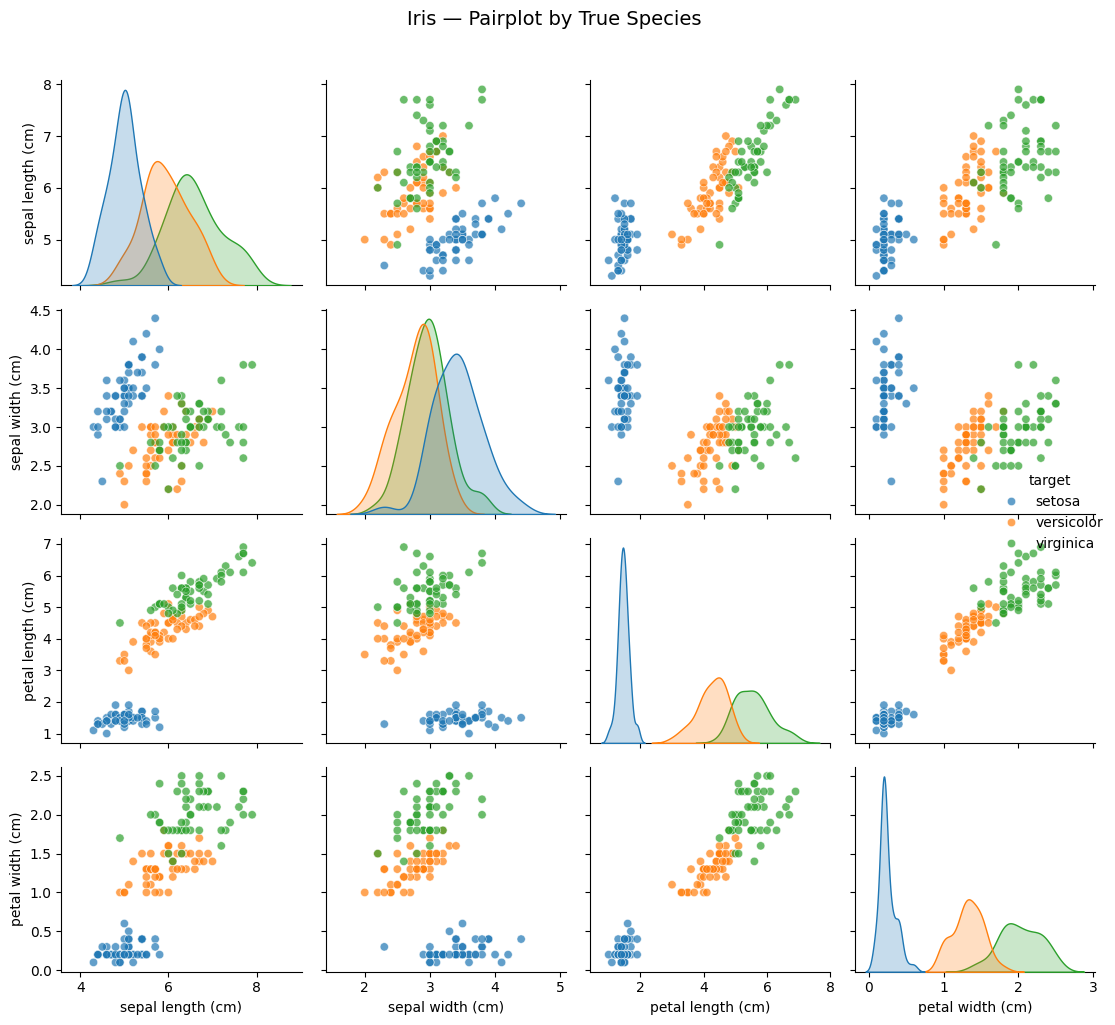

In [35]:
sns.pairplot(df, hue='target', diag_kind='kde', plot_kws={'alpha': 0.7})
plt.suptitle('Iris — Pairplot by True Species', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Scaling

In [36]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=feature_names).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


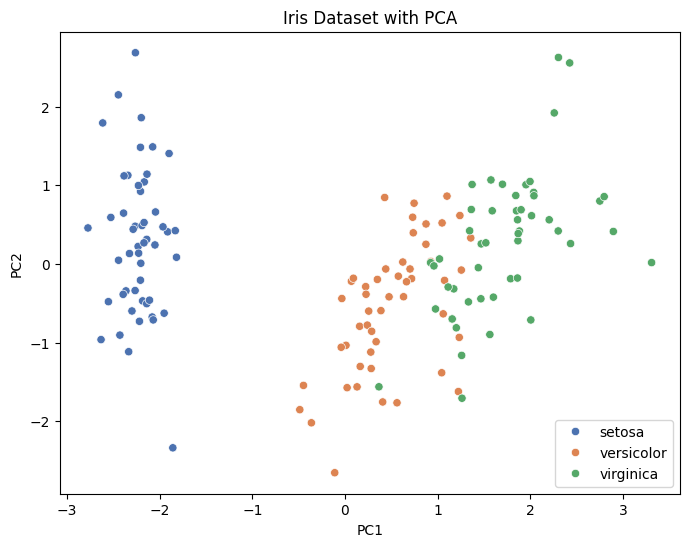

In [7]:
pca =PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=iris.target_names[y], palette='deep')
plt.title('Iris Dataset with PCA')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


# Appy Elbow Method & Silhouette Score

In [15]:
inertias = []
sil_scores = []
krange = range(2, 15)
for K in krange:
  km = KMeans(n_clusters=K, random_state=42, n_init=10)
  labels = km.fit_predict(X_scaled)
  inertias.append(km.inertia_)
  sil_scores.append(silhouette_score(X_scaled, labels))

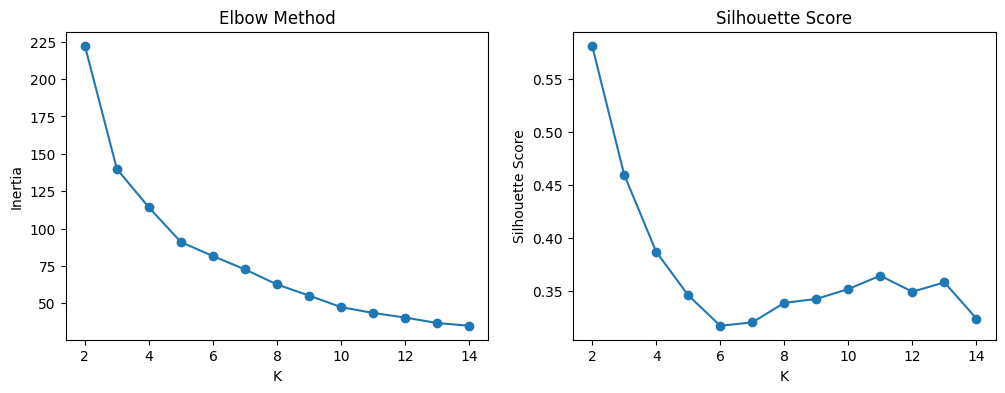

In [16]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(krange, inertias, '-o')
plt.xlabel('K'); plt.ylabel('Inertia');plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(krange, sil_scores, '-o')
plt.xlabel('K'); plt.ylabel('Silhouette Score');plt.title('Silhouette Score')
plt.show()

In [37]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_scaled)
labels = kmeans.labels_

df['cluster'] = labels
print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())
print(f'\nInertia : {kmeans.inertia_:.4f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, labels):.4f}')

Cluster sizes:
cluster
0    53
1    50
2    47
Name: count, dtype: int64

Inertia : 139.8205
Silhouette Score: 0.4599


In [43]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
klabels = kmeans.fit_predict(X_scaled)
print("Silhouette Score (k=3):", round(silhouette_score(X_scaled, klabels),3))

Silhouette Score (k=3): 0.46


# Drow the Centers

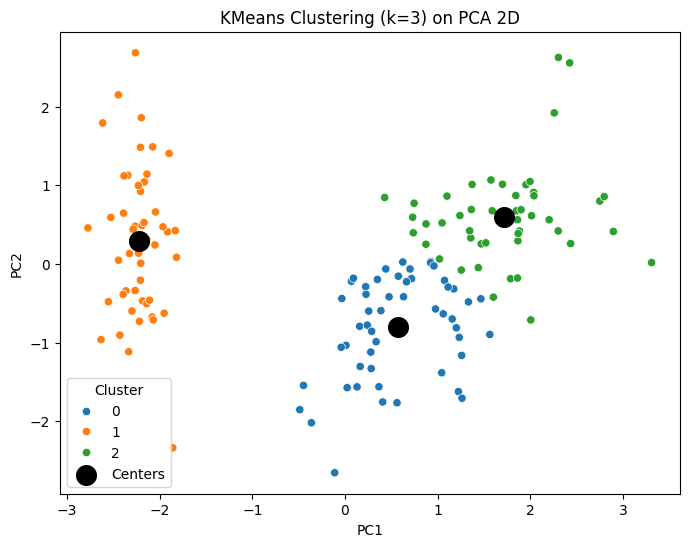

In [42]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=klabels, palette="tab10", legend="full")
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c='black', s=200, marker="o" , label= "Centers")
plt.title(f"KMeans Clustering (k={k}) on PCA 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()



# Hierarchical

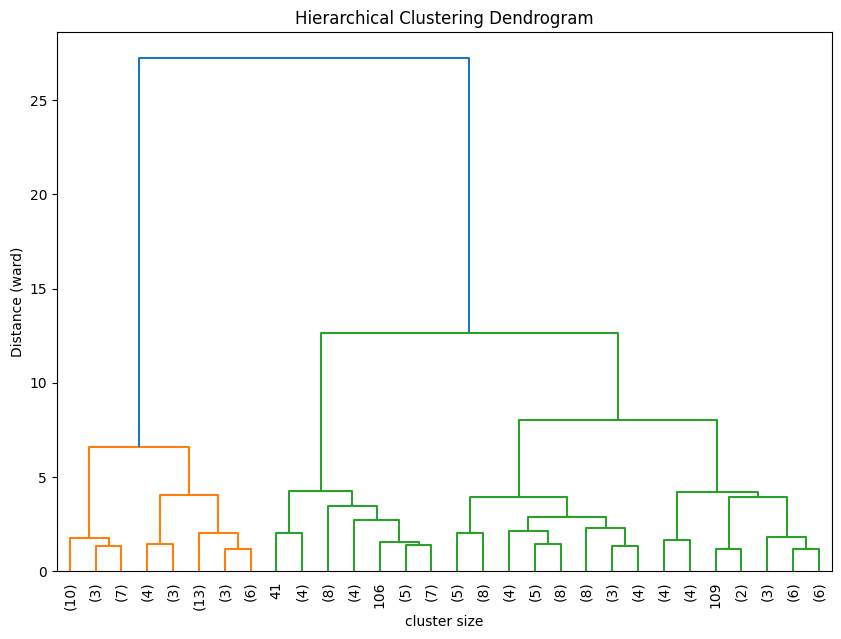

In [24]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=90.,leaf_font_size=10.)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel("cluster size")
plt.ylabel("Distance (ward)")
plt.show()

In [25]:
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
alabels= agg.fit_predict(X_scaled)
print("Silh score", round(silhouette_score(X_scaled, alabels),3))

Silh score 0.447
